In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Data generation
from src.data_generation.measurement_bias_world import simulate_measurement_bias_world

# Training utilities
from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import train_mlp_model, plot

# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff


In [3]:
df = simulate_measurement_bias_world(10000)
df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,1,62.545608,86.865592,5.072914,0
1,0,0,55.231365,153.180936,6.594844,1
2,0,0,53.519348,88.593873,5.475431,0
3,0,1,48.373756,102.911988,5.015624,0
4,2,1,58.322332,150.055766,7.276621,1


In [4]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 8000
Test size: 2000
Prevalence: 0.20175


In [8]:
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)


In [5]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUROC:", lr_results["AUROC"])


LR Accuracy: 0.997
LR AUROC: 0.9999274969474566


Epoch 1/50: train_loss=0.0387, train_acc=98.49, val_loss=0.0091, val_acc=99.75
Epoch 2/50: train_loss=0.0173, train_acc=99.50, val_loss=0.0101, val_acc=99.70
Epoch 3/50: train_loss=0.0175, train_acc=99.44, val_loss=0.0086, val_acc=99.75
Epoch 4/50: train_loss=0.0153, train_acc=99.46, val_loss=0.0088, val_acc=99.70
Epoch 5/50: train_loss=0.0161, train_acc=99.47, val_loss=0.0109, val_acc=99.60
Epoch 6/50: train_loss=0.0155, train_acc=99.49, val_loss=0.0076, val_acc=99.75
Epoch 7/50: train_loss=0.0157, train_acc=99.46, val_loss=0.0079, val_acc=99.70
Epoch 8/50: train_loss=0.0155, train_acc=99.50, val_loss=0.0103, val_acc=99.75
Epoch 9/50: train_loss=0.0160, train_acc=99.53, val_loss=0.0077, val_acc=99.70
Epoch 10/50: train_loss=0.0151, train_acc=99.47, val_loss=0.0099, val_acc=99.70
Epoch 11/50: train_loss=0.0145, train_acc=99.49, val_loss=0.0085, val_acc=99.70
Epoch 12/50: train_loss=0.0153, train_acc=99.42, val_loss=0.0090, val_acc=99.70
Epoch 13/50: train_loss=0.0140, train_acc=99.54, 

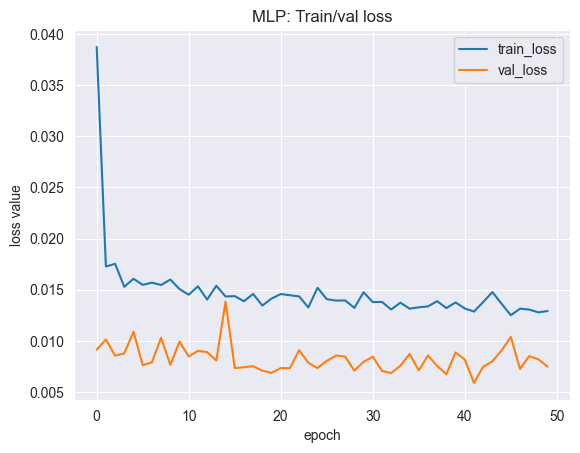

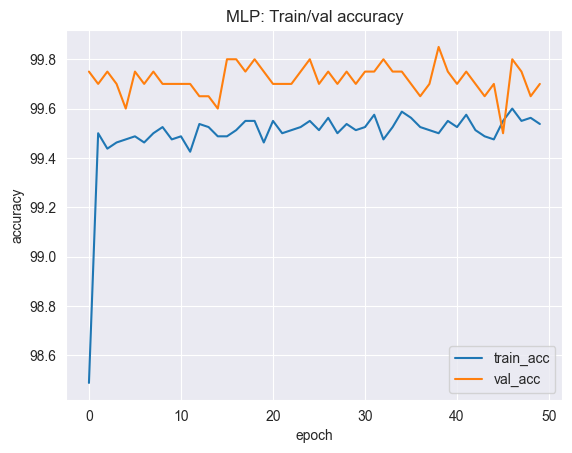

In [17]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=50,
    lr=0.01
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUROC:", mlp_results["AUROC"])


In [7]:
race_test = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

# ----------------------
# LR Fairness
# ----------------------
print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], race_test)
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], gender_test)
print(lr_fair_gender)

LR_EO_race   = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)

# ----------------------
# MLP Fairness
# ----------------------
print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], race_test)
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], gender_test)
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
      FPR       FNR       TPR     TNR
0  0.0000  0.009091  0.990909  1.0000
1  0.0025  0.031250  0.968750  0.9975
2  0.0000  0.000000  1.000000  1.0000

=== LR Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.001224  0.010811  0.989189  0.998776
1  0.000000  0.015957  0.984043  1.000000

=== MLP Fairness by Race ===
      FPR       FNR       TPR     TNR
0  0.0000  0.000000  1.000000  1.0000
1  0.0075  0.020833  0.979167  0.9925
2  0.0000  0.000000  1.000000  1.0000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.001224  0.005405  0.994595  0.998776
1  0.002469  0.005319  0.994681  0.997531


In [9]:
results_measurement_bias = {
    "world_name": "MeasurementBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,

    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_measurement_bias


{'world_name': 'MeasurementBias',
 'LR_accuracy': 0.997,
 'LR_AUROC': 0.9999274969474566,
 'LR_EO_race': 0.03125,
 'LR_EO_gender': 0.005146635997699822,
 'MLP_accuracy': np.float64(0.9975),
 'MLP_AUROC': 0.9999357359307003,
 'MLP_EO_race': 0.02083333333333337,
 'MLP_EO_gender': 8.6256469235102e-05}

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

def threshold_sweep(y_true, probs, group, n=50):
    """
    Sweep thresholds between 0.1 and 0.9 and compute EO gap (race).
    """
    thresholds = np.linspace(0.1, 0.9, n)
    eo_values = []

    for t in thresholds:
        pred = (probs > t).astype(int)
        fair_df = fairness_by_group(y_true, pred, group)
        eo_values.append(equal_opportunity_diff(fair_df))

    return thresholds, np.array(eo_values)

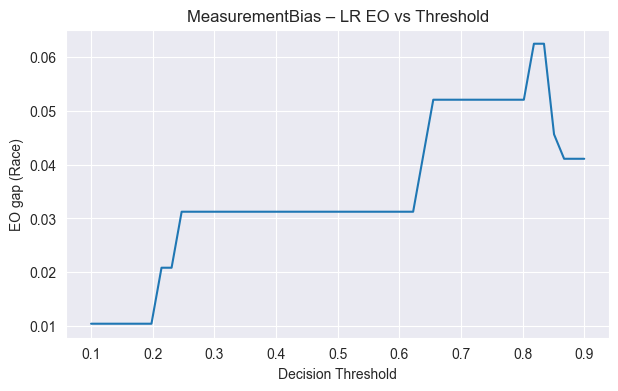

Best LR threshold: 0.1
Best LR EO gap: 0.01041666666666663

LR fairness AFTER threshold adj (Race):


In [14]:
t_lr, eo_lr = threshold_sweep(
    y_test.values,
    lr_results["probs"],
    race_test
)

plt.figure(figsize=(7,4))
plt.plot(t_lr, eo_lr)
plt.xlabel("Decision Threshold")
plt.ylabel("EO gap (Race)")
plt.title("MeasurementBias – LR EO vs Threshold")
plt.show()

best_t_lr = t_lr[np.argmin(eo_lr)]
best_eo_lr = eo_lr.min()
print("Best LR threshold:", best_t_lr)
print("Best LR EO gap:", best_eo_lr)

lr_pred_adj = (lr_results["probs"] > best_t_lr).astype(int)

print("\nLR fairness AFTER threshold adj (Race):")
lr_adj_race = fairness_by_group

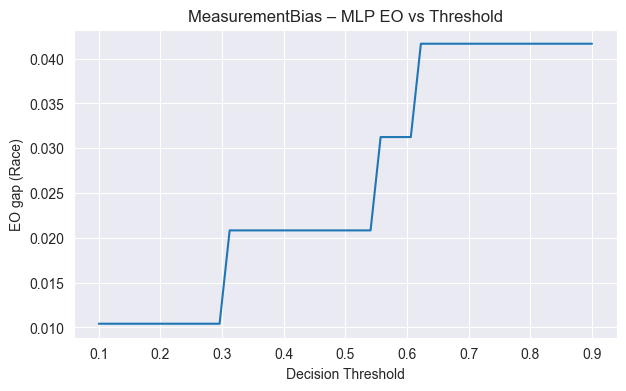

Best MLP threshold: 0.1
Best MLP EO gap: 0.01041666666666663

MLP fairness AFTER threshold adj (Race):


,FPR,FNR,TPR,TNR
0,0.002002,0.000000,1.000000,0.997998
1,0.037500,0.010417,0.989583,0.962500
2,0.000000,0.000000,1.000000,1.000000



MLP fairness AFTER threshold adj (Gender):


,FPR,FNR,TPR,TNR
0,0.012240,0.000000,1.000000,0.987760
1,0.008642,0.005319,0.994681,0.991358



MLP Accuracy before: 0.9975 after: 0.991


In [15]:
t_mlp, eo_mlp = threshold_sweep(
    y_test.values,
    mlp_results["probs"],
    race_test
)

plt.figure(figsize=(7,4))
plt.plot(t_mlp, eo_mlp)
plt.xlabel("Decision Threshold")
plt.ylabel("EO gap (Race)")
plt.title("MeasurementBias – MLP EO vs Threshold")
plt.show()

best_t_mlp = t_mlp[np.argmin(eo_mlp)]
best_eo_mlp = eo_mlp.min()
print("Best MLP threshold:", best_t_mlp)
print("Best MLP EO gap:", best_eo_mlp)

mlp_pred_adj = (mlp_results["probs"] > best_t_mlp).astype(int)

print("\nMLP fairness AFTER threshold adj (Race):")
mlp_adj_race = fairness_by_group(y_test, mlp_pred_adj, race_test)
display(mlp_adj_race)

print("\nMLP fairness AFTER threshold adj (Gender):")
mlp_adj_gender = fairness_by_group(y_test, mlp_pred_adj, gender_test)
display(mlp_adj_gender)

mlp_acc_before = mlp_results["accuracy"]
mlp_acc_after  = accuracy_score(y_test, mlp_pred_adj)
print("\nMLP Accuracy before:", mlp_acc_before, "after:", mlp_acc_after)
